In [1]:
#%pip install plotly
#%pip install squarify
#%pip install -U scikit-learn

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, OneHotEncoder,StringIndexer, Bucketizer
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType, Row
from pyspark.ml.clustering import KMeans
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score
from IPython.display import display, HTML
from datetime import datetime
from pyspark.sql.functions import concat_ws
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import plotly.express as px
import seaborn as sns
import pandas as pd
import re
import squarify
import glob

In [3]:
#creating the session and the Sparkcontext for RDD manipulation
spark = SparkSession.builder.appName("CRM Analysis").getOrCreate()
sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [4]:
# Recuperation des donnees 
salesData = sc.textFile("./Data/input/International_sale_Report.csv")

In [5]:
# Lire la premiere ligne qui represente l'entete
salesHeader = salesData.first()
salesHeader = salesHeader.split(',')
salesHeader

['index',
 'DATE',
 'Months',
 'CUSTOMER',
 'Style',
 'SKU',
 'Size',
 'PCS',
 'RATE',
 'GROSS AMT']

In [6]:
#remove header from the rdd
salesData = sc.parallelize(salesData.collect()[1:])
nbLines = salesData.count()
'number of lines :', nbLines

('number of lines :', 37432)

In [7]:
# Il faut que les donnees soit de type tuple et non pas list, car on aura besoin de les hasher apres
salesData = salesData.map(lambda str: tuple(str.split(',')))

# Probleme 1 :

- Il y a un swap entre les donnees au niveau des colonnes DATE,Size,PCS,RATE et GROSS AMT. Donc on split les lignes la ou le probleme commence on aurait donc deux rdd, clean et unclean data.


In [8]:
#regex pour detecter les dates, format : jj-MM-yy
dateRe = re.compile("^[0-9]{1,2}\\-[0-9]{1,2}\\-[0-9]{2}$")
cleanData = salesData.filter(lambda l: dateRe.match(l[1])) 
uncleanData = salesData.filter(lambda l: not(dateRe.match(l[1])))

# Probleme 2:

- Dans les donnees non propres, il y a des intrus qui sont les Stock Keeping Unit (SKU). Dans la gestion des stocks, une unité de gestion des stocks est l'unité de mesure dans laquelle les stocks d'un article sont gérés.


In [9]:
skuData = uncleanData.filter(lambda elt: elt[2]=='' and elt[1]!='')
#.map(lambda elt: [elt[0],elt[1]])
skuData.take(2)
#save this to a file

[('18635', 'SKU', '', '', '', '', '', '', '', ''),
 ('18636', 'JNE3826', '', '', '', '', '', '', '', '')]

# Probleme 3:

- Il existe des donnees sur les articles sans aucune info relier a une vent


In [10]:
StyleAndStock= uncleanData.filter(lambda elt: elt[2]!='' and elt[3] =='' )
#.map(lambda elt: [elt[0],elt[1],elt[2]])
StyleAndStock.take(2)

[('18660', 'Style', 'Stock', '', '', '', '', '', '', ''),
 ('18661', 'MEN5004', '43.00', '', '', '', '', '', '', '')]

# Resolution du 1er probleme:

- On retire l'ensemble des donnees qu'on a pu filtrer pour a la fin avoir les donnes avec les colonne swapees.
- Apres on remet l'ordre correct des colonnes en les sauvgardant dans un nouveau RDD `cleanData2`


In [11]:
rest = set(salesData.collect()) - set(cleanData.collect()) - set(StyleAndStock.collect()) - set(skuData.collect())
rest = sc.parallelize(rest)
rest.take(1)

[('27068',
  'VISHA DEVAN',
  '12-14-21',
  'Dec-21',
  'SHIPPING',
  'SHIPPING',
  '1.00',
  '2875.00',
  '2875.00',
  '0.00')]

In [12]:
#swap between two columns 1 <-> 2 then 2 <-> 3 so that it matches the clean data schema
cleanData2 = rest.map(lambda elt:  [elt[0],elt[2],elt[3],elt[1],elt[4],elt[5],None,elt[6],elt[7],elt[8]])

# probleme 4:

- La colonne size est vide pour une bonne partie des donnees

# Solution:

- On remarque que la taille est aussi dispo dans la derniere partie du SKU, XXX-XX-__{L}__ par ex, donc on recupere la taille de l'attr SKU


In [13]:
def fixSize(elt):
    if(elt[6] == None):
        sku = elt[5].split('-')
        elt[6] = sku[len(sku)-1]
    return elt


cleanData2 = cleanData2.filter(lambda elt: elt[5]!='')
cleanData2.map(fixSize).take(1)

[['27068',
  '12-14-21',
  'Dec-21',
  'VISHA DEVAN',
  'SHIPPING',
  'SHIPPING',
  'SHIPPING',
  '1.00',
  '2875.00',
  '2875.00']]

# Probleme 5:

- Environs 1400 ligne de donnees n'a pa de SKU et c'est un facteur important, donc on dois enlever ces ligne pour ne pas avoir des resultats fausses


In [14]:
cleanData = cleanData.filter(lambda elt: elt[5]!='')
cleanData.take(1)

[('0',
  '06-05-21',
  'Jun-21',
  'REVATHY LOGANATHAN',
  'MEN5004',
  'MEN5004-KR-L',
  'L',
  '1.00',
  '616.56',
  '617.00')]

In [15]:
{
    'Donnees propres':cleanData.count() + cleanData2.count(), 
    'Donnees non propres': StyleAndStock.count() + skuData.count()
}

{'Donnees propres': 34958, 'Donnees non propres': 1039}

In [16]:
print(f"Donnees initial:\t{salesData.count()} lignes\nDonnees utillisable apres nettoyage:\t"+
f"{cleanData.count() + cleanData2.count()}lignes")

Donnees initial:	37432 lignes
Donnees utillisable apres nettoyage:	34958lignes


# Sauvgarde des donnees


In [43]:
finalCleanRdd = cleanData.union(cleanData2)
finalDf = spark.createDataFrame(finalCleanRdd,schema=salesHeader)
finalDf.show(5)

+-----+--------+------+------------------+-------+--------------+----+----+------+---------+
|index|    DATE|Months|          CUSTOMER|  Style|           SKU|Size| PCS|  RATE|GROSS AMT|
+-----+--------+------+------------------+-------+--------------+----+----+------+---------+
|    0|06-05-21|Jun-21|REVATHY LOGANATHAN|MEN5004|  MEN5004-KR-L|   L|1.00|616.56|   617.00|
|    1|06-05-21|Jun-21|REVATHY LOGANATHAN|MEN5004| MEN5004-KR-XL|  XL|1.00|616.56|   617.00|
|    2|06-05-21|Jun-21|REVATHY LOGANATHAN|MEN5004|MEN5004-KR-XXL| XXL|1.00|616.56|   617.00|
|    3|06-05-21|Jun-21|REVATHY LOGANATHAN|MEN5009|  MEN5009-KR-L|   L|1.00|616.56|   617.00|
|    4|06-05-21|Jun-21|REVATHY LOGANATHAN|MEN5011|  MEN5011-KR-L|   L|1.00|616.56|   617.00|
+-----+--------+------+------------------+-------+--------------+----+----+------+---------+
only showing top 5 rows



In [44]:
# Ecrire le donnees dans le disque
#df.write.mode('overwrite').csv("./Data/output/",header = True)

# Cross-selling analysis


In [45]:
def readData(path) :
    #defining a schema for the data 
    schema = StructType([
        StructField("index", IntegerType(), False),
        StructField("DATE", StringType(), False),
        StructField("Months", StringType(), False),
        StructField("CUSTOMER", StringType(), False),
        StructField("Style", StringType(), False),
        StructField("SKU", StringType(), False),
        StructField("Size", StringType(), False),
        StructField("PCS", DoubleType(), False),
        StructField("RATE", DoubleType(), False),
        StructField("GROSS AMT", DoubleType(), False)
    ])

    # Load data
    data = spark.read.format("csv")\
        .option("header", True)\
        .option("nullValue","")\
        .schema(schema)\
        .load(path)
    
    #dropping null data
    data = data.na.drop()
    return data

Pour les algorithmes de Data mining il est conseille de travailler avec des donnes numerique et non pas avec des chaine de charactere, et donc pour chaque element important de type string on va l'indexer pour obtenir un valeur numerique utilisable par la suite 

In [46]:
def indexData(data):
    # Creating indexers for string
    styleIndexer = StringIndexer(inputCol="Style",outputCol="StyleIndex", handleInvalid = "error")
    skuIndexer = StringIndexer(inputCol="SKU",outputCol="SKUIndex",  handleInvalid = "error")
    sizeIndexer = StringIndexer(inputCol="Size",outputCol="SizeIndex",  handleInvalid = "error")
    # Fits the model
    data = styleIndexer.fit(data).transform(data)
    data = skuIndexer.fit(data).transform(data)
    data = sizeIndexer.fit(data).transform(data)
    return data

In [47]:
def encodeData(data):
    # One-hot encode categorical features
    style_encoder = OneHotEncoder(inputCol="StyleIndex", outputCol="StyleVec")
    sku_encoder = OneHotEncoder(inputCol="SKUIndex", outputCol="SKUVec")
    size_encoder = OneHotEncoder(inputCol="SizeIndex", outputCol="SizeVec")
    data = style_encoder.fit(data).transform(data)
    data = sku_encoder.fit(data).transform(data)
    data = size_encoder.fit(data).transform(data)
    return data

In [48]:
def assembleData(data):
    # Create vector assembler
    assembler = VectorAssembler(inputCols=["StyleVec", "SKUVec", "SizeVec", "PCS", "RATE", "GROSS AMT"], outputCol="features")
    data_with_features = assembler.transform(data)
    return data_with_features


In [49]:
dataPaths = glob.glob('./Data/output/*.csv')
# Read Data
data = readData(dataPaths[1])
# Index string values
indexedData = indexData(data)
# One-hot encode categorical features 
encodedData = encodeData(indexedData)
#  Create vector assembler
data_with_features = assembleData(encodedData)


# Cluster the data to identify potential cross-selling and upselling opportunities
kmeans = KMeans(k=10, seed=1)
model = kmeans.fit(data_with_features.select("features"))

# Predict the cluster labels for each data point
predictions = model.transform(data_with_features)

# Show the predicted clusters for each SKU and Style combination
predictions.groupBy("Style", "SKU", "prediction").count().sort("prediction", "count", ascending=[0,1]).show()

+--------+-----------------+----------+-----+
|   Style|              SKU|prediction|count|
+--------+-----------------+----------+-----+
|  SET389|   SET389-KR-NP-M|         9|    1|
|   J0278|   J0278-SET-XXXL|         9|    1|
|   J0034|    J0034-SET-XXL|         9|    1|
|  SET055|   SET055-KR-NP-L|         9|    1|
|   J0279|     J0279-SET-XL|         9|    1|
|   J0037|     J0037-KR-XXL|         9|    1|
|  SET249|   SET249-KR-NP-S|         9|    1|
|   J0134|      J0134-SET-S|         9|    1|
|  SET389|  SET389-KR-NP-XL|         9|    1|
|   J0333|     J0333-DR-XXL|         9|    1|
|   NW005|    NW005-ST-PJ-L|         9|    1|
|  SET303|   SET303-KR-NP-S|         9|    1|
|   J0093|      J0093-DR-XL|         9|    1|
|   J0148|      J0148-SET-M|         9|    1|
|  SET182|SET182-KR-DH-XXXL|         9|    1|
|  SET223|   SET223-KR-NP-M|         9|    1|
|   J0006|      J0006-SET-S|         9|    1|
|   J0187|      J0187-KR-XS|         9|    1|
|  SET389|SET389-KR-NP-XXXL|      

In [50]:
predictions = predictions.groupBy("Style", "SKU", "prediction").count().sort("prediction", "count", ascending=[0,1])
type(predictions)

pyspark.sql.dataframe.DataFrame

## Affichage des resultats

In [51]:
predictions_pd = predictions.toPandas()
fig = px.bar(predictions_pd,x='prediction',y='count')
fig.show()

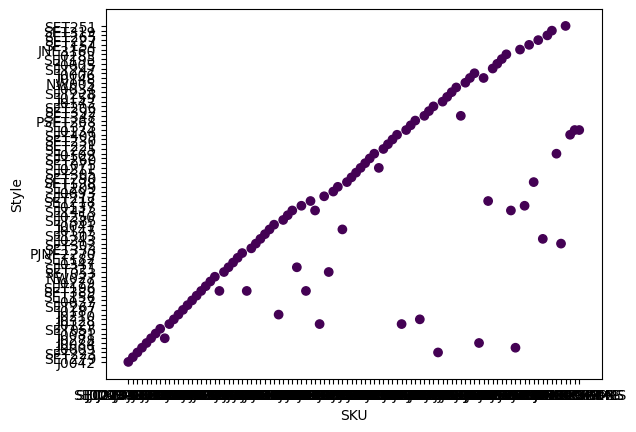

In [52]:
# Convert predictions dataframe to Pandas dataframe
predictions_pd = predictions.select("Style", "SKU", "prediction").limit(100).toPandas()

# Create scatter plot
plt.scatter(predictions_pd["SKU"], predictions_pd["Style"], c=predictions_pd["prediction"])
plt.xlabel("SKU")
plt.ylabel("Style")


plt.show()


# RFM Analysis


In [53]:

files = glob.glob("./Data/output/*.csv")
rfmRdd = sc.parallelize([])
#reading the data from the source files:
for f in files:
    #removing the header before hand
    rdd = sc.parallelize(sc.textFile(f).collect()[1:])
    #adding the rdd to the uniting
    rfmRdd = rfmRdd.union(rdd)


#splting the lines so we can deal with them
rfmRdd = rfmRdd.map(lambda elt: elt.split(','))

#filtering data that dont have a date
dateReg = r'[00-12]-[00-31]-[00-99]'
dateReg = re.compile(dateRe)
rfmRdd = rfmRdd.filter(lambda elt : dateRe.match(elt[1]))

In [54]:

def stringToDate(elt):
    elt[1] = datetime.strptime(elt[1],'%m-%d-%y')
    return elt
rfmRdd = rfmRdd.map(stringToDate)
maxDate = rfmRdd.map(lambda l : l[1]).max()
#maxDate = datetime.strftime(maxDate,'%m-%d-%y')
maxDate

datetime.datetime(2022, 3, 31, 0, 0)

On prend un jour proche du max pour avoir des resultats raisonable


In [55]:

# Om simule qu'on fait les analyses le jours apres la derniere transactions
today = datetime(2022,4,1)
rowsRdd = rfmRdd.map(lambda l: Row(
    index = l[0],
    date = l[1],
    customer = l[3],
    totalPrice = float(l[9])
))
groupedRdd = rowsRdd.groupBy(lambda row: row.customer)\
    .mapValues(lambda rows: (
        (today - max([row.date for row in rows])).days,
        len(set(row.index for row in rows)),
        sum(row.totalPrice for row in rows)
    ))
# les elements sont groupe par client  
groupedRdd.take(2)

[('VISHA DEVAN', (41, 766, 692446.0)),
 ('KALAIVANI PERMALU', (98, 636, 379736.0))]

In [56]:
# creation d'un data frame apartir des donnees groupee
rfm = groupedRdd.map(lambda elt: (elt[0],elt[1][0],elt[1][1],elt[1][2]))\
    .toDF(['Customer','Recence','Frequence','Monetary'])
rfm.show()

+--------------------+-------+---------+---------+
|            Customer|Recence|Frequence| Monetary|
+--------------------+-------+---------+---------+
|         VISHA DEVAN|     41|      766| 692446.0|
|   KALAIVANI PERMALU|     98|      636| 379736.0|
|        BISSY SKARIA|     66|       78|  55192.0|
|             AANCHOL|    259|        9|  26065.0|
|    PUVANES GANNASIN|    165|      129|  89770.0|
| MULBERRIES BOUTIQUE|     39|     3756|3649692.0|
|   NIRUSAH TAILORING|    178|      726| 692640.0|
|    DANESHWARY RAMAR|      4|      281| 218710.0|
|       RINA THAKURTA|     36|      296| 412188.0|
|          MR.JEYARAJ|      6|      277| 177550.0|
|     ABBI COLLECTION|     55|      142|  83628.0|
| MRS DEVIANEE BALLAH|    162|      158| 132692.0|
|  MANISH DHOORUNDHUR|    198|       41|  30264.0|
|              SINDHU|     46|      223| 204020.0|
|PUNITHAVATHY KARU...|     35|      284| 270416.0|
|     YASSHLINY KUNJU|     29|      243| 196044.0|
| RISHIKESH DASHPUTRE|    247| 

In [57]:
def getRfmScore(dataframe):
    df_ = dataframe
    # Calculating the quantiles
    recencySplits = (df_.approxQuantile("Recence",[0.0,0.25,0.5,0.75,1.0],0.1))
    frequencySplit = (df_.approxQuantile("Frequence",[0.0,0.25,0.5,0.75,1.0],0.1))
    monetarySplit = df_.approxQuantile("Monetary",[0.0,0.25,0.5,0.75,1.0],0.1)
    print('RFM splits:',{
        'recency': recencySplits, 'frequency': frequencySplit, 'monetary': monetarySplit
    })
    #segmenting the values accordingly
    recencyBucket = Bucketizer(splits=(recencySplits),inputCol="Recence",outputCol="recence_score")
    frequencyBucket = Bucketizer(splits=frequencySplit,inputCol="Frequence",outputCol="frequence_score")
    monetaryBucket = Bucketizer(splits=monetarySplit,inputCol="Monetary",outputCol="monetary_score")
    df_ = recencyBucket.transform(df_)
    df_ = frequencyBucket.transform(df_)
    df_ = monetaryBucket.transform(df_)
    # create the rfm score which is the concatenation of the 3 values R, F, M
    df_ = df_.withColumn("RFM_SCORE", concat_ws("", df_["recence_score"].cast("int").cast("string"),
                                                 df_["frequence_score"].cast("int").cast("string"),
                                                 df_["monetary_score"].cast("int").cast("string")
                                                )
                        )

    return df_

In [58]:
rfmScores = getRfmScore(rfm)

RFM splits: {'recency': [1.0, 29.0, 78.0, 175.0, 297.0], 'frequency': [9.0, 46.0, 129.0, 277.0, 3756.0], 'monetary': [12916.0, 40536.0, 99516.0, 204020.0, 3649692.0]}


In [59]:
rfmScores.show(5)

+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
|         Customer|Recence|Frequence|Monetary|recence_score|frequence_score|monetary_score|RFM_SCORE|
+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
|      VISHA DEVAN|     41|      766|692446.0|          1.0|            3.0|           3.0|      133|
|KALAIVANI PERMALU|     98|      636|379736.0|          2.0|            3.0|           3.0|      233|
|     BISSY SKARIA|     66|       78| 55192.0|          1.0|            1.0|           1.0|      111|
|          AANCHOL|    259|        9| 26065.0|          3.0|            0.0|           0.0|      300|
| PUVANES GANNASIN|    165|      129| 89770.0|          2.0|            2.0|           1.0|      221|
+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
only showing top 5 rows



## Segmentation

In [60]:
def matchSegment(value, segMap):
    for pattern in segMap:
        regex = re.compile(pattern)
        if regex.match(value):
            return segMap[pattern]
    return value

# Define the segment map
segMap = {
    r'^[0-1][3-4][3-4]$' : 'Champions',
    r'^[0-4][3-4][0-4]$' : 'Loyal',
    r'^[0-2]2[0-4]$' : 'Prometteur',
    r'^[0-1][0-2]{2}$' : 'Rookie',
    r'^[2-3][0-2][3-4]$': 'High value',
    r'^[3-4][0-2][0-4]$': 'Dormant',
    r'^[0-4][0-1][0-2]$' : 'En risque',
}

# Create a UDF to replace the values based on the segment map dictionary
udf_replace = F.udf(lambda x: matchSegment(x, segMap))

# Apply the UDF to the RFM_SCORE column and create a new column called 'segment'
rfmMap = rfmScores.withColumn('segment', udf_replace(F.col('RFM_SCORE')))


In [61]:
rfmMap.sort("segment").write.mode('overwrite').csv("Data/processed/",header = True)

### Segmentation Map visualisation

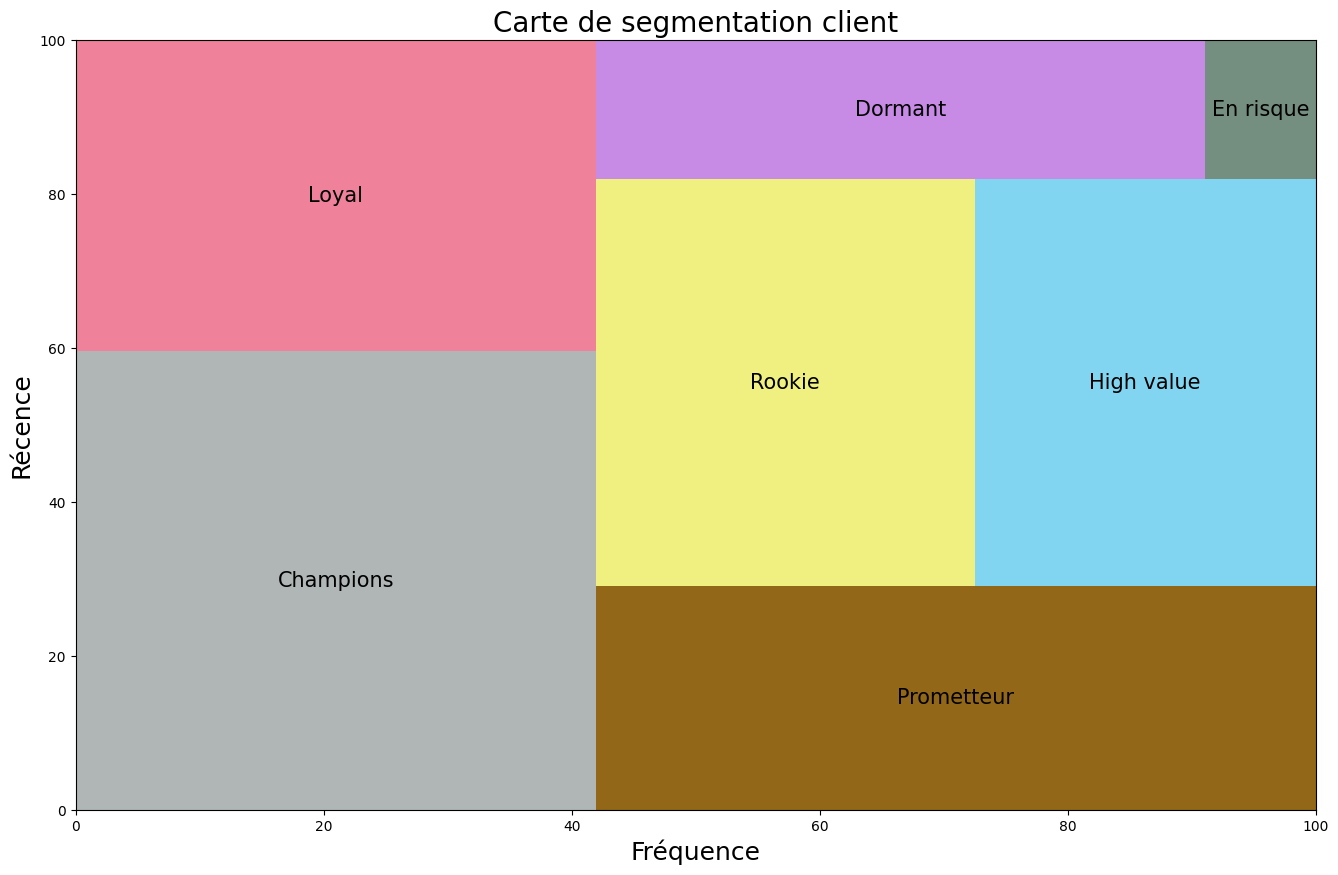

In [62]:
# Transformer en pandas DF pour visualiser les donnees
pandasRfmDf = rfmMap.sort("segment").toPandas()

segments = pandasRfmDf["segment"].value_counts().sort_values(ascending = False)

fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 10)
squarify.plot(
    sizes=segments,
    label=[label for label in segMap.values()],
    color=[
        "#AFB6B5",
        "#F0819A",
        "#926717",
        "#F0F081",
        "#81D5F0",
        "#C78BE5",
        "#748E80",
        "#FAAF3A",
        "#7B8FE4",
        "#86E8C0",
    ],
    pad=False,
    bar_kwargs={"alpha": 1},
    text_kwargs={"fontsize": 15},
)

plt.title("Carte de segmentation client", fontsize=20)
plt.xlabel("Fréquence", fontsize=18)
plt.ylabel("Récence", fontsize=18)
plt.show()


In [63]:
pandasRfmDf.head(20)

,Customer,Recence,Frequence,Monetary,recence_score,frequence_score,monetary_score,RFM_SCORE,segment
0,VISHA DEVAN,41,766,692446.0,1.0,3.0,3.0,133,Champions
1,MULBERRIES BOUTIQUE,39,3756,3649692.0,1.0,3.0,3.0,133,Champions
2,DANESHWARY RAMAR,4,281,218710.0,0.0,3.0,3.0,033,Champions
3,RINA THAKURTA,36,296,412188.0,1.0,3.0,3.0,133,Champions
4,PUNITHAVATHY KARUPIAH,35,284,270416.0,1.0,3.0,3.0,133,Champions
5,VAHARSHA BOUTIQUE,48,1445,1290440.0,1.0,3.0,3.0,133,Champions
6,FUSION FASHIONS CORP.,22,835,621487.0,0.0,3.0,3.0,033,Champions
7,SHILPI KUMARI,29,807,533130.0,1.0,3.0,3.0,133,Champions
8,IBRAHIM MAFTHOOH(JANASYA.IN),27,480,430850.0,0.0,3.0,3.0,033,Champions
9,AVIN,1,634,423581.0,0.0,3.0,3.0,033,Champions


In [64]:
X = pandasRfmDf[['recence_score','frequence_score']]
labels = pandasRfmDf['segment']
results = {
    'Nombre d\'Observations': [X.shape[0]],
    'Nombre de Segment': [labels.nunique()],
    'Silouhette score': [round(silhouette_score(X,labels),3)],
    'Calinski Harabasz Score': [round(calinski_harabasz_score(X,labels),3)],
    'Davies Bouldin Score': [round(davies_bouldin_score(X,labels),3)]
}

df_results = pd.DataFrame(results)
df_results.head().T


,0
Nombre d'Observations,124.000
Nombre de Segment,7.000
Silouhette score,0.441
Calinski Harabasz Score,93.824
Davies Bouldin Score,0.818


## Analyse des segments

In [65]:
pandasRfmDf[['Recence','Monetary','Frequence','segment']]\
.groupby('segment')\
.agg({'mean','std','max','min'})

Recence                            Monetary            \
                  mean  min  max        std           mean       min   
segment                                                                
Champions    28.523810    1   55  14.814247  636153.095238  218710.0   
Dormant     239.903226  177  297  36.630911   54998.354839   12916.0   
En risque   115.818182   78  165  32.868886   75024.363636   38600.0   
High value  236.500000  192  281  62.932504  357876.000000  342716.0   
Loyal       160.444444    6  266  58.588517  597244.444444  177550.0   
Prometteur   83.300000   22  170  53.157264  140876.900000   83628.0   
Rookie       32.904762    3   74  25.426177   65814.523810   20965.0   

                                       Frequence                         
                  max            std        mean  min   max         std  
segment                                                                  
Champions   3649692.0  732963.020299  768.571429  281  3756  751.848427  
Dormant      185882.0   44493.280319   63.677419    9   247   52.472461  
En risque    141360.0   37736.313734   84.272727   38   126   27.785215  
High value   373036.0   21439.477606  202.500000  150   255   74.246212  
Loyal       2034416.0  432359.238641  584.277778  277  1316  295.305187  
Prometteur   234086.0   42098.640661  171.000000  129   272   38.892565  
Rookie       153552.0   29265.676891   74.952381   13   128   34.015403

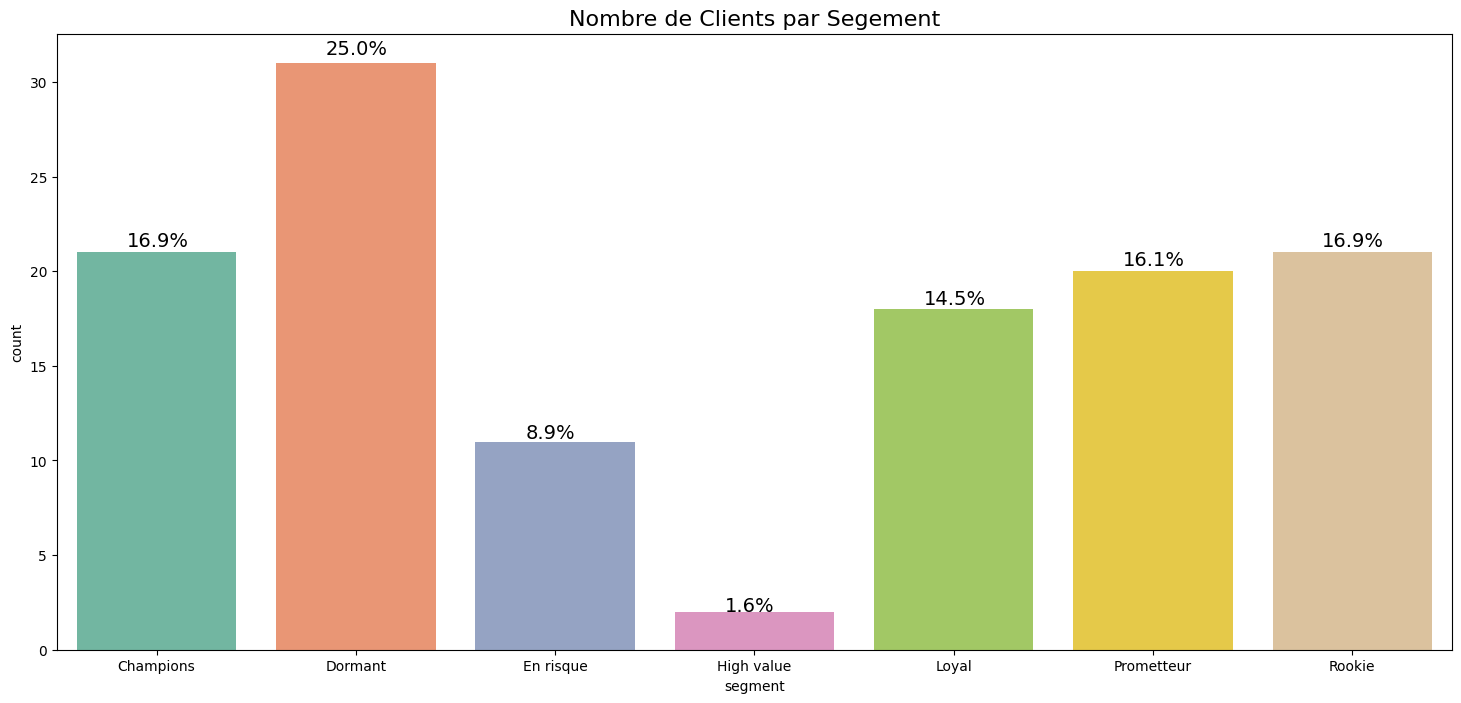

In [66]:
plt.figure(figsize=(18,8))
ax = sns.countplot(data = pandasRfmDf,
                   x='segment',
                   palette='Set2')
total = len(pandasRfmDf.segment)

#calculer le pourcentage et l'afficher
for patch in ax.patches:
    percentage = '{:.1f}%'.format(100 * patch.get_height()/total)
    x = patch.get_x() + patch.get_width( ) / 2 - 0.15
    y = patch.get_y() + patch.get_height( ) * 1.015
    ax.annotate(percentage, (x,y), size = 14)

plt.title('Nombre de Clients par Segement',size=16)
plt.xticks(size = 10)
plt.yticks(size = 10)
plt.show()

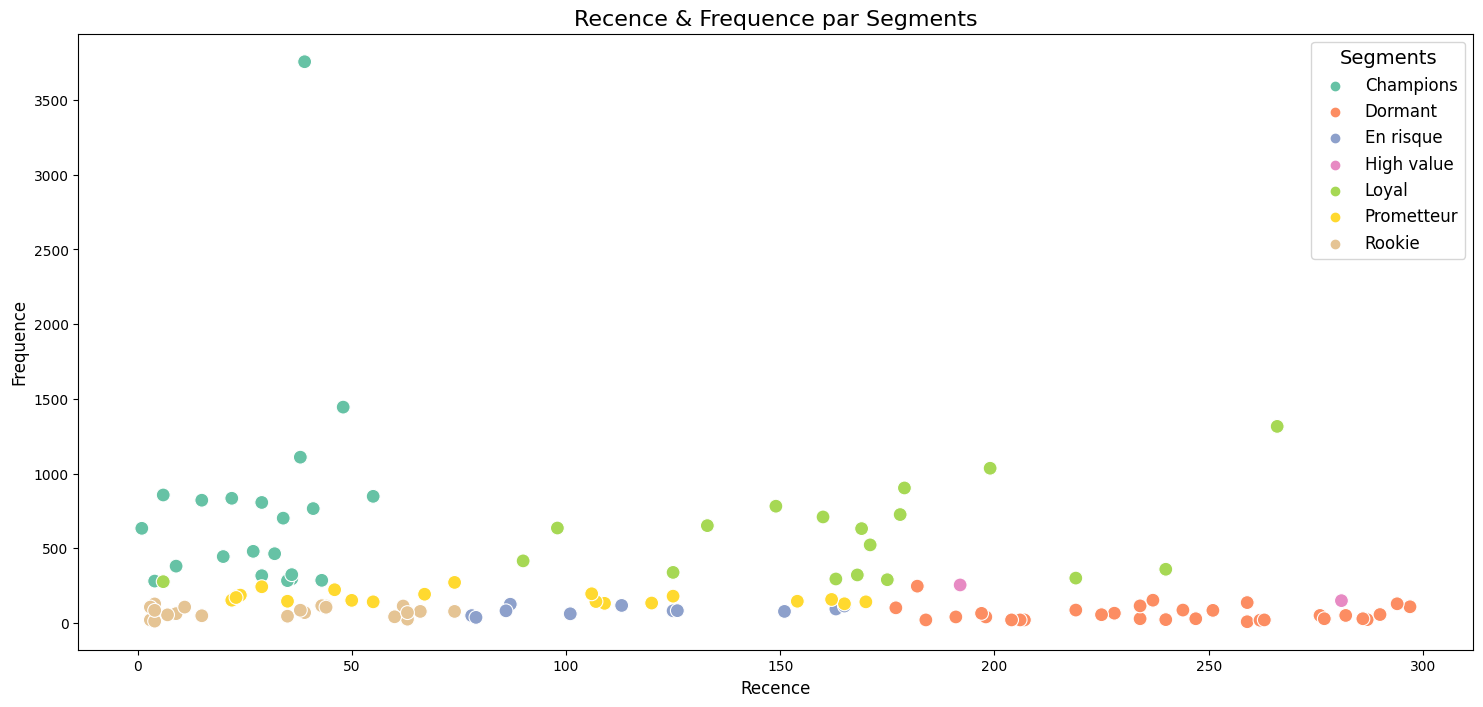

In [67]:
plt.figure(figsize=(18, 8))
sns.scatterplot(
    data=pandasRfmDf, x="Recence", y="Frequence", hue="segment", palette='Set2', s=100
)
plt.title("Recence & Frequence par Segments", size=16)
plt.xlabel("Recence", size=12)
plt.ylabel("Frequence", size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.legend(loc="best", fontsize=12, title="Segments", title_fontsize=14)
plt.show()

# Cohort Analysis

In [74]:
from operator import attrgetter
import matplotlib.colors as mcolors

def CohortAnalysis(dataframe):

    data = dataframe.copy()
    data = data[["CUSTOMER", "index", "DATE"]].drop_duplicates()
    #converting to date like as it doesnt recognize the mm-dd-yy
    data["DATE"] = pd.to_datetime(data["DATE"],infer_datetime_format=True) 
    data["order_month"] = data["DATE"].dt.to_period("M")
    data["cohort"] = (
        data.groupby("CUSTOMER")["DATE"].transform(
            "min").dt.to_period("M")
    )
    cohort_data = (
        data.groupby(["cohort", "order_month"])
        .agg(n_customers=("CUSTOMER", "nunique"))
        .reset_index(drop=False)
    )
    cohort_data["period_number"] = (cohort_data.order_month - cohort_data.cohort).apply(
        attrgetter("n")
    )
    cohort_pivot = cohort_data.pivot_table(
        index="cohort", columns="period_number", values="n_customers"
    )
    cohort_size = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    with sns.axes_style("white"):
        fig, ax = plt.subplots(
            1, 2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]}
        )
        sns.heatmap(
            retention_matrix,
            mask=retention_matrix.isnull(),
            annot=True,
            cbar=False,
            fmt=".0%",
            cmap="coolwarm",
            ax=ax[1],
        )
        ax[1].set_title("Monthly Cohorts: User Retention", fontsize=14)
        ax[1].set(xlabel="# of periods", ylabel="")
        white_cmap = mcolors.ListedColormap(["white"])
        sns.heatmap(
            pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"}),
            annot=True,
            cbar=False,
            fmt="g",
            cmap=white_cmap,
            ax=ax[0],
        )
        fig.tight_layout()

In [76]:
pandaPd = finalDf.toPandas()
pandaPd = pandaPd[~(pandaPd['DATE']== 'DATE')]
#pandaPd

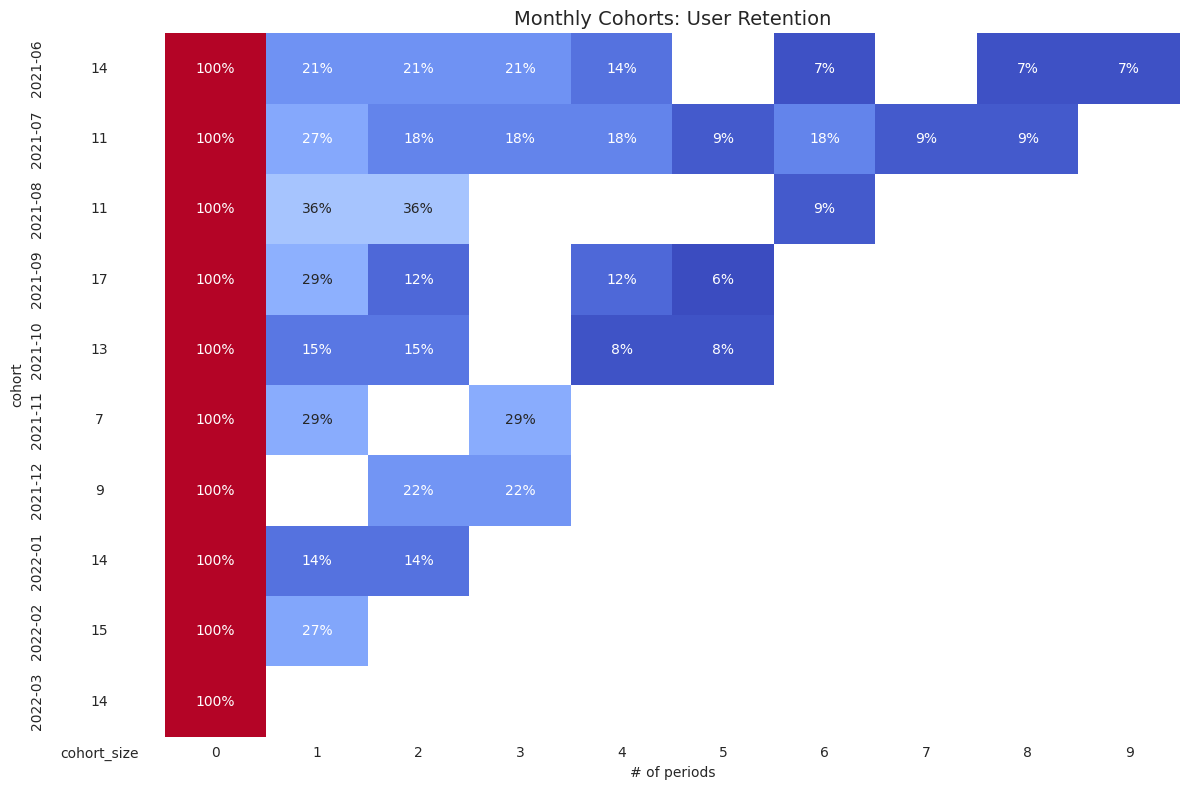

In [77]:

CohortAnalysis(pandaPd)